## Implementation of Isolation Forest to Detect Outliers in Python (Scikit-learn)

### 1. Preparation
#### 1.1. Input data

The data "sample_detect_outliers.csv" contains US public firms' features that are related to leases (my dissertation is on leases).

#### 1.2. Output data
The following lines of code will output an indicator variable that equals 1 if the firm (e.g., observation) is an outlier and 0 otherwise. For more details on the steps after I identify outliers, please see my dissertation, <a href="https://papers.ssrn.com/sol3/papers.cfm?abstract_id=3689446">Yoon (2022)</a>.

#### 1.3. Feature (i.e., variable) definition
- *lag_lease*: prior year's lease activity<br>
- *lag_market_value*: prior year's market capitalization of the stock<br>
- *lag_dividend*: an indicator value that equals 1 if the company paid any dividends in the prior, and 0 otherwise<br>
- *lag_loss*: an indicator value that equals 1 if the company reported negative profits in the prior year<br>
- *lag_cash*: prior year's cash balance<br>
- *lag_tax_rate*: effective tax rate in the prior year<br>
- *lag_big4_auditor*: an indicator value that equals 1 if the company hired a Big 4 auditor in the prior year<br>

#### 1.4. Import libraries and the data set

In [1]:
# Import libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

Взяла ноутбук из репозитория https://github.com/youngdataspace/Detect-Outliers-Using-Isolation-Forest 
Для скорости прямо в него подставляю наши данные от 15.09.2024

In [10]:
!dir ..\data

 Volume in drive C has no label.
 Volume Serial Number is 0A0C-B955

 Directory of C:\Users\T570\PycharmProjects\Price\data

11/06/2024  03:25 PM    <DIR>          .
11/06/2024  03:25 PM    <DIR>          ..
11/06/2024  03:24 PM           410,044 df_coded
11/06/2024  03:24 PM         1,034,820 df_full
11/06/2024  03:24 PM         1,269,387 df_norm
11/06/2024  03:24 PM           831,724 df_nothing
10/28/2024  11:34 AM         1,032,067 Full_df
10/28/2024  11:34 AM        38,447,710 test_data.csv
10/28/2024  11:34 AM             1,108 ???????? ? ????
               7 File(s)     43,026,860 bytes
               2 Dir(s)  405,678,886,912 bytes free


In [14]:
# Import the data set
# sample_with_outliers = pd.read_csv('../data/df_coded.csv.csv', on_bad_lines='warn')
sample_with_outliers = pd.read_csv('../data/df_full.csv')

### 2. Conduct an Exploratory Data Analysis (EDA)
#### 2.1. Show the first 5 entries in the data

In [15]:
# First 5 entries
sample_with_outliers.head()

,floor_count,lat,lon,area,area_kitchen,balcony_info,floor,house_type,price_object,rooms_count,sanuzel_multiple,type_flat,renovation,selling_type,normalized_price,year_build,elevator
0,0.354839,0.253957,0.458621,0.206024,0.107143,0.000000,0.40,1.0,0.136044,0.625,0.5,0.0,0.666667,0.875,0.217291,0.648649,0.0
1,0.548387,0.559701,0.861844,0.151807,0.228571,0.000000,0.56,0.8,0.161459,0.375,0.5,0.0,0.333333,0.875,0.342914,0.810811,0.0
2,0.129032,0.610807,0.709239,0.043373,0.081429,0.500000,0.08,0.4,0.042677,0.250,0.0,0.0,0.666667,0.875,0.273025,0.900901,0.0
3,0.258065,0.611371,0.532692,0.190361,0.114286,0.000000,0.28,0.4,0.123678,0.500,0.5,0.0,0.666667,0.875,0.213211,0.549550,0.0
4,0.032258,0.535272,0.768592,0.103614,0.085714,0.289137,0.00,0.2,0.057517,0.500,0.0,0.0,0.666667,0.875,0.179513,0.099099,0.0


#### 2.2. The # of entries and the # of features
There are 6,279 entries and 9 variables = 1 identifier + 1 label (i.e., outcome variable) + 7 firm features. The second variable, *lease*, is the label.


In [16]:
# (Number of entries, Number of features)
print(sample_with_outliers.shape)

(4764, 17)


#### 2.3. Empirical distributions and histograms
There are many interesting observations that are worth noting. First, there are no missing values as indicated by counts that all equal 6,279. I discuss other interesting observations in the next section.

In [17]:
# Show empirical distributions
sample_with_outliers.describe()

,floor_count,lat,lon,area,area_kitchen,balcony_info,floor,house_type,price_object,rooms_count,sanuzel_multiple,type_flat,renovation,selling_type,normalized_price,year_build,elevator
count,4764.000000,4764.000000,4764.000000,4764.000000,4764.000000,4764.000000,4764.000000,4764.000000,4764.000000,4764.000000,4764.000000,4764.000000,4764.000000,4764.000000,4764.000000,4764.000000,4764.000000
mean,0.273767,0.495848,0.656632,0.095047,0.131127,0.289137,0.172334,0.627162,0.081798,0.356415,0.223066,0.059824,0.599286,0.764798,0.262880,0.630400,0.126154
std,0.182351,0.134719,0.168713,0.055948,0.074496,0.253223,0.171599,0.319026,0.067754,0.121537,0.252152,0.237185,0.265528,0.328760,0.095047,0.238091,0.332058
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.129032,0.405135,0.507477,0.059759,0.085714,0.000000,0.040000,0.400000,0.045768,0.250000,0.000000,0.000000,0.333333,0.875000,0.198530,0.423423,0.000000
50%,0.258065,0.515966,0.651233,0.082410,0.114286,0.289137,0.120000,0.600000,0.063700,0.375000,0.000000,0.000000,0.666667,0.875000,0.240654,0.603604,0.000000
75%,0.290323,0.588195,0.796517,0.118072,0.152857,0.500000,0.240000,1.000000,0.093998,0.375000,0.500000,0.000000,0.666667,1.000000,0.305992,0.864865,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


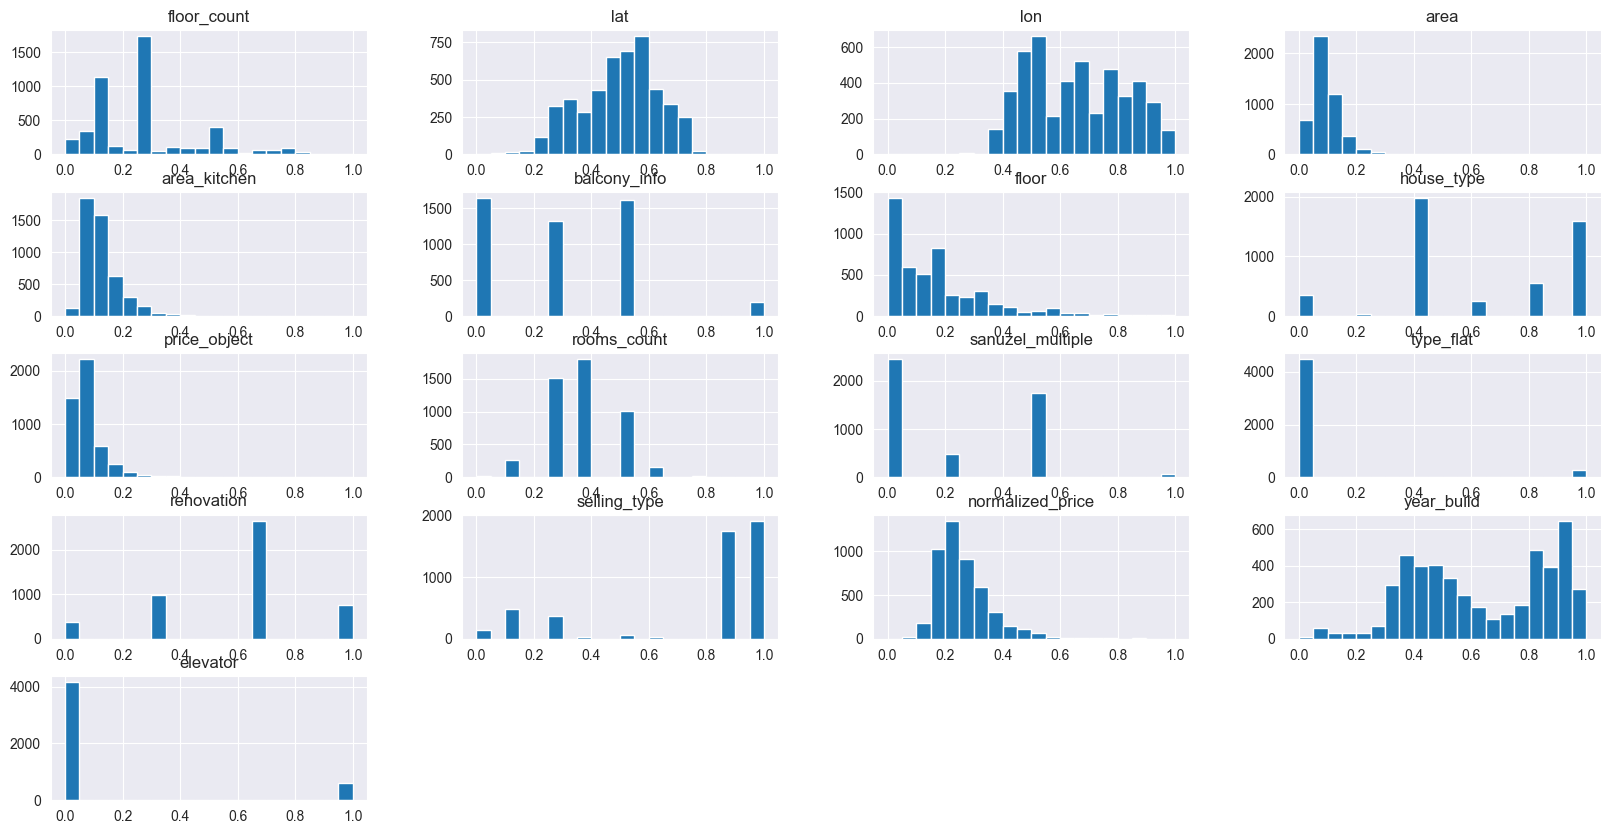

In [19]:
# Show histograms - all variables except for the identifier
# sample_z = sample_with_outliers.drop(columns='identifier')
sample_z = sample_with_outliers.copy()
sample_z.hist(bins = 20, figsize =(20, 10))
plt.show()

#### 2.4. Drop variables without outliers
The above two panels show that *lag_loss* and *lag_big4_auditor* are indicator variables and thus do not have outliers. 

In addition, the histogram suggests that *lag_tax_rate* also does not have outliers. During the sample period (2016-2019), the corporate tax rate was reduced from 35% to 21%. Two big spikes in the histogram around 35% and 21% and all other values smaller than 35% make economic sense.

Therefore, I drop these three variables that do not have outliers.

In [7]:
# Drop identifier, lag_loss, lag_big4_auditor, and lag_tax_rate 
var = ['identifier', 'lag_loss', 'lag_big4_auditor', 'lag_tax_rate']
sample_z = sample_with_outliers.drop(columns=var)

### 3. Z-Score - Detect and Remove Outliers
Before implementing Isolation Forest, I will first attempt to detect outliers using the Z-score method.

As indicated in a previous section, the Z-Score method is effective in addressing outliers for data points that follow a normal distribution.

The z-score indicates the distance of a data point from the mean as the number of standard deviations. The formula is as follows:

<img src="https://github.com/youngdataspace/treat-outliers/blob/main/Z%20Score.JPG?raw=true">


I am going to assume that observations with a Z-score below -2.5 or above 2.5 (i.e., 2.5 standard deviations away from the mean; 1% of the sample) are outliers.

#### 3.1. *lag_market_value* - Identify and remove outliers
The histogram above shows that *lag_market_value* follows a normal distribution. To detect outliers, I first write a function to print the upper limits and lower limits of the Z-Score.

In [21]:
# Create a function to report the limits of the Z-Score
def print_z_score_limits (df, column_name):
    """ Print the upper and lower limits of the Z-score """
    
    # Compute the limits
    upper_limit = df[column_name].mean() + 3 * df[column_name].std()
    lower_limit = df[column_name].mean() - 3 * df[column_name].std()
    
    # Round and return the limits
    upper_limit = round(upper_limit, 2)
    lower_limit = round(lower_limit, 2)
    print_this = "Variable Name: " + column_name + " | Upper limit: " + str(upper_limit) + " | Lower limit: " + str(lower_limit)
    return(print_this)

In [22]:
# Print the upper and lower limits
print_z_score_limits(sample_z, "lag_market_value")

KeyError: 'lag_market_value'

It turns out that all of the values (N=6,279) are within the boundary values of 2.43 and 12.82. Thus, none of the observations are trimmed.

In [10]:
# Filter outliers
sample_z = sample_z[(sample_z['lag_market_value'] >= 2.43) | (sample_z['lag_market_value'] <= 12.82)]
print(sample_z.shape)

(6279, 5)


I'll drop lag_market_value since an outlier treatment is not necessary for this feature.

In [11]:
# Drop lag_market_value
sample_z = sample_z.drop(columns=['lag_market_value'])

#### 3.2. Log transformation of other variables
Going back to the histogram above, we can see that *lease*, *lag_lease*, *lag_dividend*, and *lag_cash* are all significantly right-skewed. In this case, the Z-Score method or many other popular outlier detection methods such as the Interquartile Range (IQR) method won't do any good. To address this issue, I conduct log transformations on these variables to see if I can describe them with normal distribution.

The histogram also shows that the four variables have many zeros (or very small values), which make economic sense. Therefore, I will only look for outliers on the right-hand side of the distribution. 

First, I will replace zeros with NaNs. This is okay because zeros will not be considered outliers.

In [12]:
# Replace zeros with NaNs
sample_z['lag_dividend'] = sample_z['lag_dividend'].replace([0],np.NaN)
sample_z['lease'] = sample_z['lease'].replace([0],np.NaN)

Next, I perform the log transformations and plot histograms

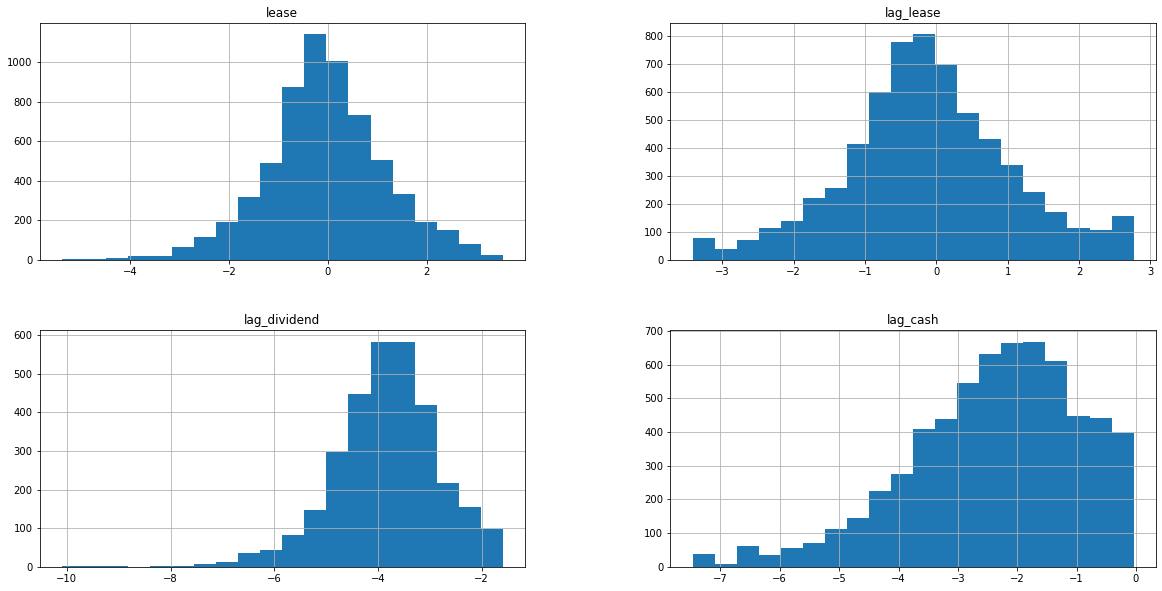

In [13]:
# Create a function to conduct log transformation
def log_transformation_function (df, column_name):
    """ Conduct a log transformation of a variable """
    # Replace the values with log-transformed values
    df[[column_name]] = df[[column_name]].apply(np.log)

# Conduct log transformation on all the variables
for column in sample_z:
    log_transformation_function(sample_z, column)   
    
# Plot histograms
sample_z.hist(bins = 20, figsize =(20, 10))
plt.show()

#### 3.3. Other variables - Identify and remove outliers
The distributions now look much more like normal distributions. Once again, I will use the Z-Score to identify outliers.

First, I report the Z-Score upper limits for each variable.

In [14]:
# Print the upper and lower limits
for column in sample_z:
    print(print_z_score_limits(sample_z, column))

Variable Name: lease | Upper limit: 3.55 | Lower limit: -3.64
Variable Name: lag_lease | Upper limit: 3.42 | Lower limit: -3.66
Variable Name: lag_dividend | Upper limit: -0.8 | Lower limit: -6.86
Variable Name: lag_cash | Upper limit: 1.97 | Lower limit: -6.76


Next, I report the maximum values of each variable.

In [15]:
# Print the maximum values
print("MAXIMUM VALUES")
print(round(sample_z.max(),2))   

MAXIMUM VALUES
lease           3.54
lag_lease       2.76
lag_dividend   -1.59
lag_cash       -0.04
dtype: float64


All of the maximum values are smaller than the upper limits. Thus, none of the variables seems to have outliers.

### 4. Isolation Forest - Multi-dimensional Outlier Detection
Although the data points do not seem to have outliers at the variable level, there could be outliers at a multi-dimensional  level. Therefore, I employ Isolation Forest to detect outliers.

#### 4.1. Setup
I begin by dropping the identifier from the original sample.

In [23]:
sample_isf = sample_with_outliers.copy()

#### 4.2. Conduct Principal Component Analysis (PCA)
I conduct PCA to reduce the firm feature dimensions from 7 to 2. Note that this step is not necessary because Isolation Forest works fine with multi-dimensions. Regardless, I reduce dimensions to visualize the outlier points in my data.

In [17]:
# Standardize features
sample_scaled = StandardScaler().fit_transform(sample_isf)

# Define dimensions = 2
pca = PCA(n_components=2)       

# Conduct the PCA
principal_comp = pca.fit_transform(sample_scaled)     

# Convert to dataframe
pca_df = pd.DataFrame(data = principal_comp, columns = ['principal_component_1', 'principal_component_2'])
pca_df.head()

,principal_component_1,principal_component_2
0,-0.941123,-0.078371
1,-0.908097,0.062997
2,-0.984182,-0.140106
3,-0.352054,-0.265954
4,1.168329,-0.220572


#### 4.3. Train the model and make predictions
As indicated before, we need to pre-define outlier frequency. After experimenting with data, I decide to use 4%. 

In [24]:
# Train the model
isf = IsolationForest(contamination=0.04)
isf.fit(sample_isf)

# Predictions
predictions = isf.predict(sample_isf)

#### 4.4. Extract predictions and isolation scores

In [26]:
# Extract scores
sample_isf["iso_forest_scores"] = isf.decision_function(sample_isf)

# Extract predictions
sample_isf["iso_forest_outliers"] = predictions

# Describe the dataframe
sample_isf.describe()

,floor_count,lat,lon,area,area_kitchen,balcony_info,floor,house_type,price_object,rooms_count,sanuzel_multiple,type_flat,renovation,selling_type,normalized_price,year_build,elevator,iso_forest_scores,iso_forest_outliers
count,4764.000000,4764.000000,4764.000000,4764.000000,4764.000000,4764.000000,4764.000000,4764.000000,4764.000000,4764.000000,4764.000000,4764.000000,4764.000000,4764.000000,4764.000000,4764.000000,4764.000000,4764.000000,4764.000000
mean,0.273767,0.495848,0.656632,0.095047,0.131127,0.289137,0.172334,0.627162,0.081798,0.356415,0.223066,0.059824,0.599286,0.764798,0.262880,0.630400,0.126154,0.095655,0.919815
std,0.182351,0.134719,0.168713,0.055948,0.074496,0.253223,0.171599,0.319026,0.067754,0.121537,0.252152,0.237185,0.265528,0.328760,0.095047,0.238091,0.332058,0.045693,0.392393
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.139902,-1.000000
25%,0.129032,0.405135,0.507477,0.059759,0.085714,0.000000,0.040000,0.400000,0.045768,0.250000,0.000000,0.000000,0.333333,0.875000,0.198530,0.423423,0.000000,0.070782,1.000000
50%,0.258065,0.515966,0.651233,0.082410,0.114286,0.289137,0.120000,0.600000,0.063700,0.375000,0.000000,0.000000,0.666667,0.875000,0.240654,0.603604,0.000000,0.105191,1.000000
75%,0.290323,0.588195,0.796517,0.118072,0.152857,0.500000,0.240000,1.000000,0.093998,0.375000,0.500000,0.000000,0.666667,1.000000,0.305992,0.864865,0.000000,0.129831,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.172049,1.000000


Let's replace "-1" with "Yes" and "1" with "No"

In [27]:
# Replace "-1" with "Yes" and "1" with "No"
sample_isf['iso_forest_outliers'] = sample_isf['iso_forest_outliers'].replace([-1, 1], ["Yes", "No"])

# Print the first 5 firms
sample_isf.head()

,floor_count,lat,lon,area,area_kitchen,balcony_info,floor,house_type,price_object,rooms_count,sanuzel_multiple,type_flat,renovation,selling_type,normalized_price,year_build,elevator,iso_forest_scores,iso_forest_outliers
0,0.354839,0.253957,0.458621,0.206024,0.107143,0.000000,0.40,1.0,0.136044,0.625,0.5,0.0,0.666667,0.875,0.217291,0.648649,0.0,0.058852,No
1,0.548387,0.559701,0.861844,0.151807,0.228571,0.000000,0.56,0.8,0.161459,0.375,0.5,0.0,0.333333,0.875,0.342914,0.810811,0.0,0.087782,No
2,0.129032,0.610807,0.709239,0.043373,0.081429,0.500000,0.08,0.4,0.042677,0.250,0.0,0.0,0.666667,0.875,0.273025,0.900901,0.0,0.148655,No
3,0.258065,0.611371,0.532692,0.190361,0.114286,0.000000,0.28,0.4,0.123678,0.500,0.5,0.0,0.666667,0.875,0.213211,0.549550,0.0,0.128870,No
4,0.032258,0.535272,0.768592,0.103614,0.085714,0.289137,0.00,0.2,0.057517,0.500,0.0,0.0,0.666667,0.875,0.179513,0.099099,0.0,0.109523,No


In [28]:
sample_isf.groupby('iso_forest_outliers').size()

iso_forest_outliers
No     4573
Yes     191
dtype: int64

In [29]:
sample_isf[sample_isf['iso_forest_outliers'] == 'Yes']

,floor_count,lat,lon,area,area_kitchen,balcony_info,floor,house_type,price_object,rooms_count,sanuzel_multiple,type_flat,renovation,selling_type,normalized_price,year_build,elevator,iso_forest_scores,iso_forest_outliers
19,0.677419,0.552322,0.951757,0.515663,0.714286,0.500000,0.84,0.8,1.000000,0.625,0.500000,0.0,0.666667,0.875,0.676021,0.882883,0.0,-0.138040,Yes
32,0.677419,0.552322,0.951757,0.450361,0.714286,0.500000,0.84,0.8,0.910961,0.625,0.500000,0.0,0.666667,0.875,0.701767,0.882883,0.0,-0.139902,Yes
35,0.193548,0.595035,0.867992,0.684337,0.428571,0.500000,0.16,0.4,0.544139,1.000,1.000000,0.0,0.000000,0.875,0.271289,0.702703,1.0,-0.110393,Yes
39,0.677419,0.552322,0.951757,0.363855,0.285714,0.500000,0.72,0.6,0.744941,0.500,0.500000,0.0,0.666667,0.875,0.703175,0.882883,0.0,-0.095113,Yes
49,0.516129,0.515050,0.924123,0.491566,1.000000,0.500000,0.64,0.8,0.296685,0.750,1.000000,0.0,0.333333,0.875,0.201739,0.765766,0.0,-0.095843,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4696,0.290323,0.726827,0.371846,0.024096,0.060732,0.289137,0.36,1.0,0.039251,0.125,0.223066,1.0,0.666667,0.000,0.359732,0.981982,0.0,-0.013684,Yes
4697,0.290323,0.726827,0.371846,0.016867,0.052056,0.289137,0.36,1.0,0.033402,0.125,0.223066,1.0,0.666667,0.000,0.372836,0.981982,0.0,-0.017482,Yes
4703,0.290323,0.726827,0.371846,0.021687,0.057840,0.289137,0.00,1.0,0.036840,0.125,0.223066,1.0,0.666667,0.000,0.360089,0.981982,0.0,-0.007259,Yes
4704,0.290323,0.726827,0.371846,0.014458,0.049164,0.289137,0.00,1.0,0.030820,0.125,0.223066,1.0,0.666667,0.000,0.372476,0.981982,0.0,-0.009501,Yes


#### 4.5. Plots
Plot the firms in the 2-dimensional space in the following order.<br>
[1] All firms<br>
[2] Normal Firms vs. Outlier Firms<br>
[3] Isolation Forest Scores

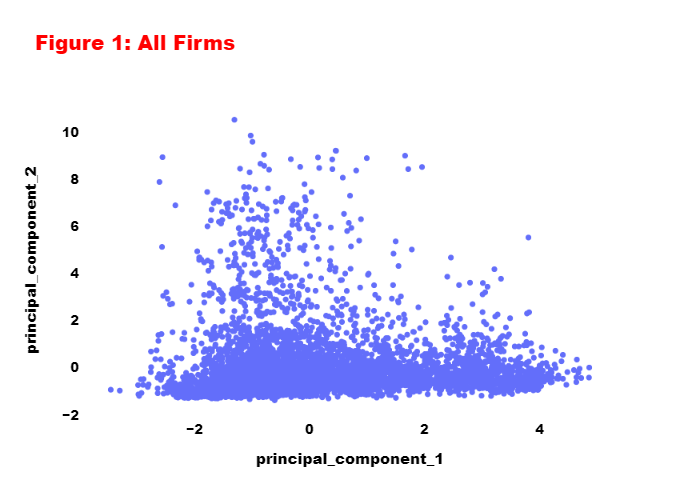

In [26]:
# Create a function to plot firms on the 2-dimensional space
def plot_firms (dataframe, title, color = None):
    """ Plot firms on the 2-dimensional space """
    
    # Generate a scatter plot
    fig = px.scatter(pca_df, x="principal_component_1", y="principal_component_2", title=title, color=color)
    
    # Layout
    fig.update_layout(
        font_family='Arial Black',
        title=dict(font=dict(size=20, color='red')),
        yaxis=dict(tickfont=dict(size=13, color='black'),
                   titlefont=dict(size=15, color='black')),
        xaxis=dict(tickfont=dict(size=13, color='black'),
                   titlefont=dict(size=15, color='black')),
        legend=dict(font=dict(size=10, color='black')),
        plot_bgcolor='white',
        # showlegend=False # Remove legend, if I want to
    )
    
    ## Hide colorbar (run the following code if I want to)
    #fig.update_coloraxes(showscale=False)
    
    return(fig)

# Need to import renderers to view the plots on GitHub
import plotly.io as pio

# Plot [1] All firms
plot_firms(pca_df, "Figure 1: All Firms").show("png")

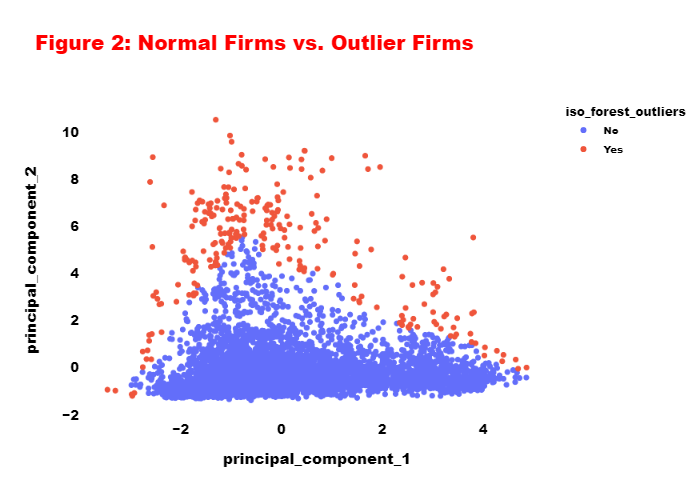

In [28]:
# [2] Normal Firms vs. Outlier Firms
plot_firms(dataframe=pca_df, title="Figure 2: Normal Firms vs. Outlier Firms", color='iso_forest_outliers').show("png")

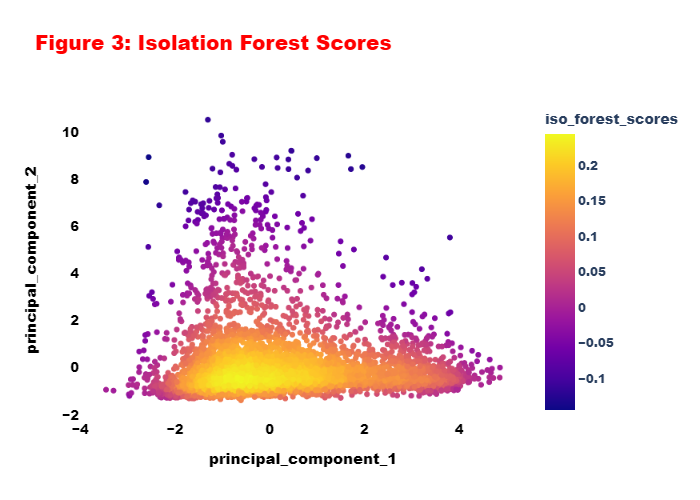

In [23]:
# [3] Isolation Forest Scores
plot_firms(dataframe=pca_df, title="Figure 3: Isolation Forest Scores", color='iso_forest_scores').show("png")

#### 4.6. Observations
A few observations are in order.

According to Figure 2, most of the outer points are identified as outliers. These outliers correctly meet the outlier characteristics that they are "distant and few."

### 5. Export and conclude

In [29]:
# Add identifiers and cluster assignments (labels) to the sample
pca_df = pd.concat([sample_with_outliers['identifier'], pca_df], axis=1)

# Print the first 5 firms
pca_df.head()

,identifier,identifier,principal_component_1,principal_component_2,iso_forest_scores,iso_forest_outliers
0,1004,1004,-0.941123,-0.078371,0.219387,No
1,1004,1004,-0.908097,0.062997,0.217918,No
2,1004,1004,-0.984182,-0.140106,0.215218,No
3,1004,1004,-0.352054,-0.265954,0.227615,No
4,1050,1050,1.168329,-0.220572,0.189528,No


In [25]:
# Export the sample as a csv file
pca_df.to_csv('outliers_detected.csv')